# Stock Market Data Visualization Project  
## Apple Inc. (AAPL)

**Course:** Data Visualization  
**Tool:** Python (VS Code, Jupyter)  
**Dataset Source:** Yahoo Finance  
**Time Period:** 2022–2024  

---

### Project Objective
The objective of this project is to acquire real-world financial data, understand its structure and limitations, and communicate insights clearly through reproducible and well-designed visualizations.


## Executive Summary

- Daily stock market data for Apple Inc. (AAPL) was collected from Yahoo Finance.
- Visual analysis shows an overall upward trend with noticeable short-term volatility.
- Moving averages reveal long-term momentum, while daily returns highlight risk patterns.
- The project demonstrates data acquisition, understanding, reproducibility, and storytelling with data.


## 1. Data Acquisition

Daily stock market data for Apple Inc. (ticker: AAPL) was obtained from Yahoo Finance using the `yfinance` Python package.

### Why this source?
- Publicly accessible and widely used
- Provides standardized financial variables (OHLCV)
- Easily reproducible using code


In [103]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

ticker = "AAPL"
start_date = "2022-01-01"
end_date = "2024-12-31"

df = yf.download(ticker, start=start_date, end=end_date)
df.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.270294,179.122429,174.058657,174.176186,104487900
2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400
2022-01-05,171.326019,176.468151,171.051773,175.919659,94537600
2022-01-06,168.466034,171.698234,168.113430,169.151649,96904000
2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100
2022-01-10,168.652100,168.955728,164.714692,165.605999,106765600
2022-01-11,171.482758,171.580694,167.310290,168.779471,76138300
2022-01-12,171.923447,173.539539,171.228043,172.501321,74805200


## 2. Data Understanding

Each row in the dataset represents **one trading day** for Apple Inc.

### Variables
- **Open** – Price at market open  
- **High** – Highest trading price of the day  
- **Low** – Lowest trading price of the day  
- **Close** – Price at market close  
- **Volume** – Number of shares traded  

### Data Collection
The data reflects executed trades during official market hours and excludes weekends and holidays.


In [104]:
df.info()


<class 'pandas.DataFrame'>
DatetimeIndex: 752 entries, 2022-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   752 non-null    float64
 1   (High, AAPL)    752 non-null    float64
 2   (Low, AAPL)     752 non-null    float64
 3   (Open, AAPL)    752 non-null    float64
 4   (Volume, AAPL)  752 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.2 KB


In [105]:
df.isna().sum()


Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

### Assumptions and Limitations
- No intraday price movements
- External factors (news, macroeconomics) are not included
- Historical performance does not predict future results


## 3. Data Preparation

Additional variables were created to support trend and risk analysis.


In [106]:
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["Daily Return"] = df["Close"].pct_change()
df.head(50)


Price,Close,High,Low,Open,Volume,MA20,MA50,Daily Return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2022-01-03,178.270294,179.122429,174.058657,174.176186,104487900,NaN,NaN,NaN
2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400,NaN,NaN,-0.012691
2022-01-05,171.326019,176.468151,171.051773,175.919659,94537600,NaN,NaN,-0.026600
2022-01-06,168.466034,171.698234,168.113430,169.151649,96904000,NaN,NaN,-0.016693
2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100,NaN,NaN,0.000988
2022-01-10,168.652100,168.955728,164.714692,165.605999,106765600,NaN,NaN,0.000116
2022-01-11,171.482758,171.580694,167.310290,168.779471,76138300,NaN,NaN,0.016784
2022-01-12,171.923447,173.539539,171.228043,172.501321,74805200,NaN,NaN,0.002570


## 4. Visualization and Analysis

### 4.1 Closing Price Trend

This visualization shows the overall movement of Apple’s stock price over time.


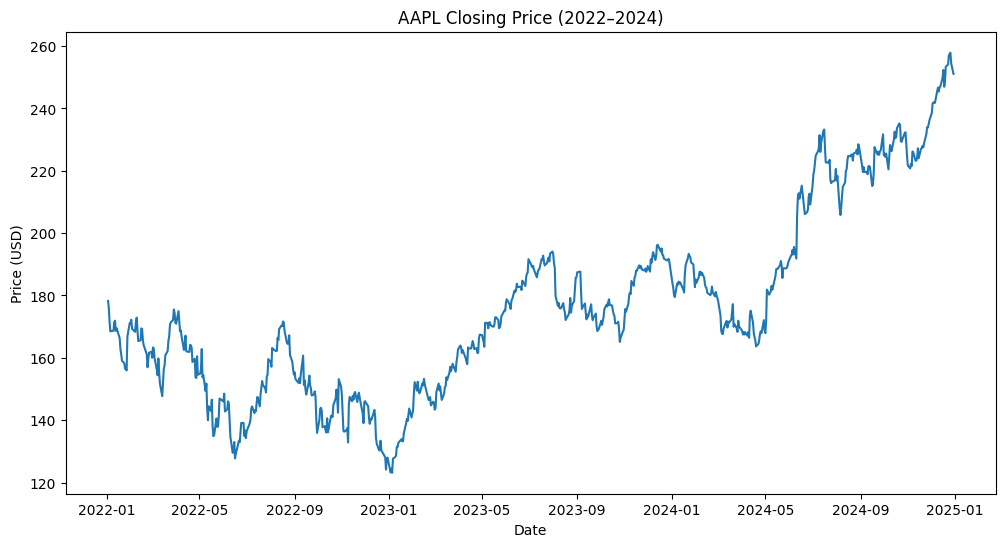

In [107]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df["Close"])
plt.title("AAPL Closing Price (2022–2024)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()


**Insight:**  
The stock price shows an overall upward trend with visible short-term fluctuations, indicating market volatility.


### 4.2 Moving Average Analysis

Moving averages help reduce daily noise and highlight long-term trends.


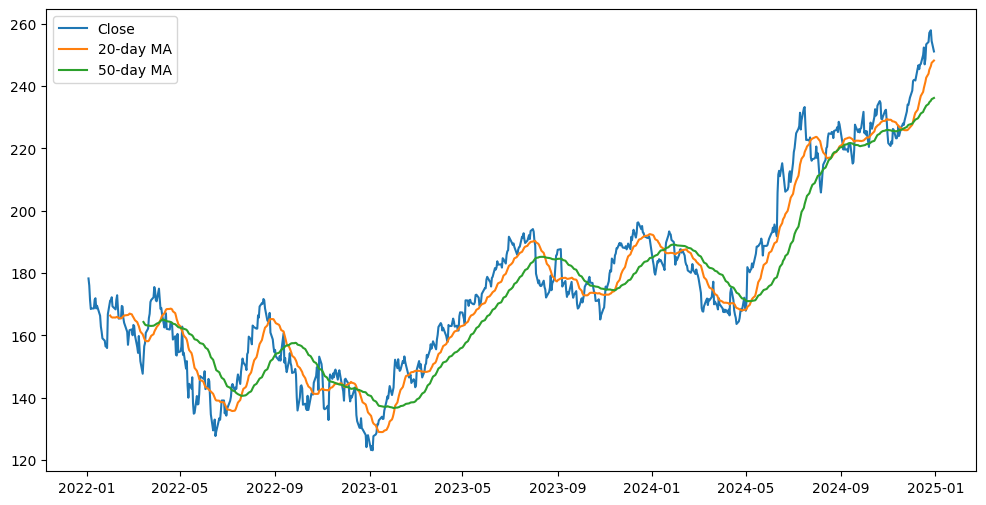

In [108]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"], label="Close")
plt.plot(df["MA20"], label="20-day MA")
plt.plot(df["MA50"], label="50-day MA")
plt.legend()
plt.show()


**Insight:**  
The moving averages confirm sustained long-term growth while smoothing temporary price shocks.


### 4.3 Risk Analysis Using Daily Returns

Daily returns are used to assess volatility and risk.


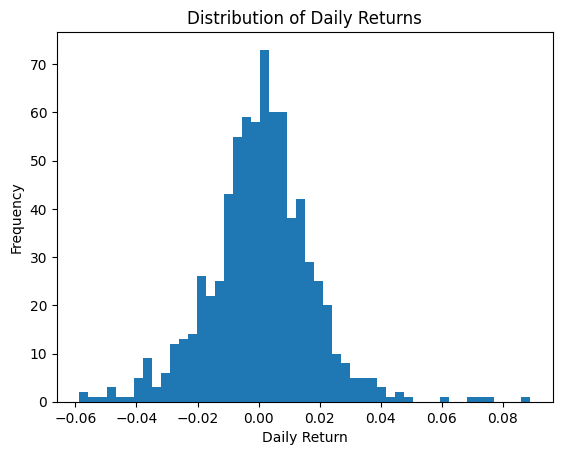

In [109]:
plt.hist(df["Daily Return"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


**Insight:**  
Most returns cluster near zero, with occasional extreme values indicating high-volatility trading days.


## 5. Reproducibility and Professional Practice

This project is reproducible because:
- Parameters (ticker and dates) are explicitly defined
- All analysis steps are clearly documented
- The dataset is saved locally


## 6. Limitations

- Analysis is limited to one stock
- External news and economic indicators are excluded
- Data frequency is daily, not intraday


## 7. Conclusion

This project demonstrated a complete data visualization workflow:
- Acquiring and understanding real financial data
- Preparing and transforming variables
- Creating clear and meaningful visualizations

Future work could include comparing multiple stocks or market indices.
